# 动力系统代理模型：插值准确不等于外推可信

## Goal

用阻尼振子的确定性轨迹训练一个轻量代理模型，分别检查训练时间范围内的插值、范围外外推、动力学残差和推理时间。

对应正文：[第 4 章：科学机器学习与计算加速](../../docs/part1-ai-foundations/chapter4.md)。

## Setup

### Key Assumptions

状态为位移 $x$ 与速度 $v$，满足

$$\dot{x}=v,\qquad \dot{v}=-2\zeta\omega v-\omega^2x.$$

使用无量纲量，参数固定为 $\omega=1.4$、$\zeta=0.12$。代理只看到 $t\leq 8$ 的样本；$t>8$ 专门用于外推检查。解析轨迹只是教学真值，并不代表真实昂贵模拟器。

In [1]:
from time import perf_counter
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 20260810
OMEGA = 1.4
ZETA = 0.12
TRAIN_END = 8.0
END_TIME = 16.0

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
    "seed": RANDOM_SEED,
})

{'python': '3.12.2', 'numpy': '2.4.0', 'scikit_learn': '1.8.0', 'seed': 20260810}


## Steps

### 1. Generate the reference trajectory

In [2]:
def reference_state(time_points, initial_state=(1.0, 0.0)):
    time_points = np.asarray(time_points)
    decay = ZETA * OMEGA
    damped_frequency = OMEGA * np.sqrt(1.0 - ZETA**2)
    initial_position, initial_velocity = initial_state
    coefficient = (initial_velocity + decay * initial_position) / damped_frequency
    exponential = np.exp(-decay * time_points)
    position = exponential * (
        initial_position * np.cos(damped_frequency * time_points)
        + coefficient * np.sin(damped_frequency * time_points)
    )
    velocity = exponential * (
        -decay * (
            initial_position * np.cos(damped_frequency * time_points)
            + coefficient * np.sin(damped_frequency * time_points)
        )
        - initial_position * damped_frequency * np.sin(damped_frequency * time_points)
        + coefficient * damped_frequency * np.cos(damped_frequency * time_points)
    )
    return np.column_stack([position, velocity])

full_time = np.linspace(0.0, END_TIME, 801)
full_state = reference_state(full_time)
assert np.allclose(full_state[0], [1.0, 0.0])

### 2. Create a held-out interpolation set and a true extrapolation set

In [3]:
training_mask = full_time <= TRAIN_END
training_candidates = np.flatnonzero(training_mask)
train_indices = training_candidates[training_candidates % 5 != 0]
interpolation_indices = training_candidates[training_candidates % 5 == 0]
extrapolation_indices = np.flatnonzero(full_time > TRAIN_END)

model = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=1,
)
model.fit(full_time[train_indices, None], full_state[train_indices])

interpolation_prediction = model.predict(full_time[interpolation_indices, None])
extrapolation_prediction = model.predict(full_time[extrapolation_indices, None])
zero_baseline = np.zeros_like(extrapolation_prediction)

metrics = pd.DataFrame(
    [
        {
            "region": "训练范围内插值",
            "model": "随机森林代理",
            "position_mae": mean_absolute_error(full_state[interpolation_indices, 0], interpolation_prediction[:, 0]),
            "velocity_mae": mean_absolute_error(full_state[interpolation_indices, 1], interpolation_prediction[:, 1]),
        },
        {
            "region": "训练范围外外推",
            "model": "随机森林代理",
            "position_mae": mean_absolute_error(full_state[extrapolation_indices, 0], extrapolation_prediction[:, 0]),
            "velocity_mae": mean_absolute_error(full_state[extrapolation_indices, 1], extrapolation_prediction[:, 1]),
        },
        {
            "region": "训练范围外外推",
            "model": "零平衡基线",
            "position_mae": mean_absolute_error(full_state[extrapolation_indices, 0], zero_baseline[:, 0]),
            "velocity_mae": mean_absolute_error(full_state[extrapolation_indices, 1], zero_baseline[:, 1]),
        },
    ]
)
metrics.round(4)

,region,model,position_mae,velocity_mae
0,训练范围内插值,随机森林代理,0.0061,0.0089
1,训练范围外外推,随机森林代理,0.0955,0.3795
2,训练范围外外推,零平衡基线,0.0920,0.1263


### 3. Inspect trajectories rather than only average error

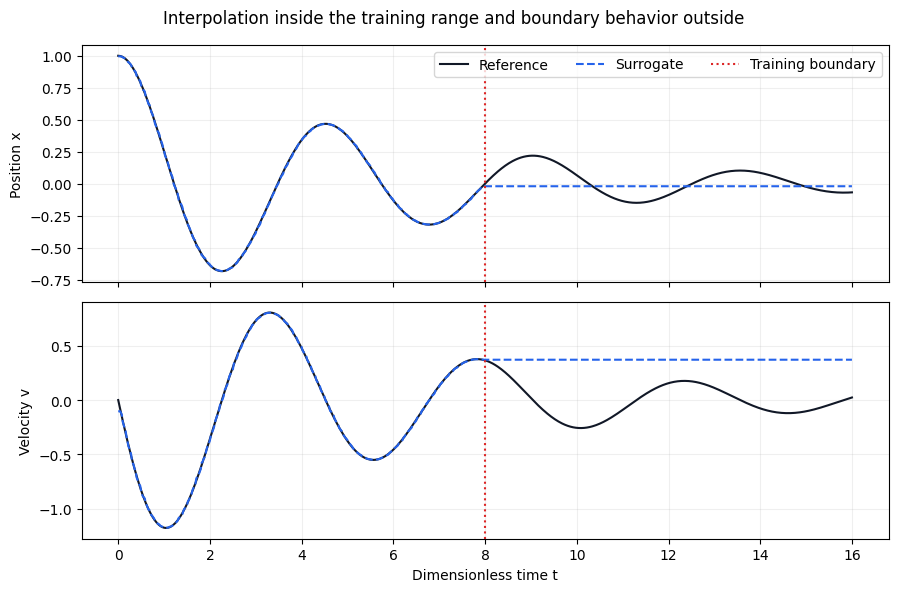

In [4]:
full_prediction = model.predict(full_time[:, None])
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
labels = [(0, "Position x"), (1, "Velocity v")]
for axis, (column, label) in zip(axes, labels):
    axis.plot(full_time, full_state[:, column], color="#111827", label="Reference")
    axis.plot(full_time, full_prediction[:, column], color="#2563eb", linestyle="--", label="Surrogate")
    axis.axvline(TRAIN_END, color="#dc2626", linestyle=":", label="Training boundary" if column == 0 else None)
    axis.set_ylabel(label)
    axis.grid(alpha=0.2)
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Dimensionless time t")
fig.suptitle("Interpolation inside the training range and boundary behavior outside")
plt.tight_layout()
plt.show()

### 4. Compute equation residuals

In [5]:
time_step = full_time[1] - full_time[0]
predicted_dx_dt = np.gradient(full_prediction[:, 0], time_step)
predicted_dv_dt = np.gradient(full_prediction[:, 1], time_step)
residual_x = predicted_dx_dt - full_prediction[:, 1]
residual_v = (
    predicted_dv_dt
    + 2.0 * ZETA * OMEGA * full_prediction[:, 1]
    + OMEGA**2 * full_prediction[:, 0]
)

residual_report = pd.DataFrame(
    {
        "region": ["训练范围", "外推范围"],
        "mean_abs_dx_minus_v": [
            np.mean(np.abs(residual_x[training_mask])),
            np.mean(np.abs(residual_x[~training_mask])),
        ],
        "mean_abs_dv_equation": [
            np.mean(np.abs(residual_v[training_mask])),
            np.mean(np.abs(residual_v[~training_mask])),
        ],
    }
)
residual_report.round(4)

,region,mean_abs_dx_minus_v,mean_abs_dv_equation
0,训练范围,0.1475,0.206
1,外推范围,0.3705,0.085


### 5. Learn the actual one-step state transition

In [6]:
PAIR_DT = 0.04
pair_time = np.arange(0.0, TRAIN_END + PAIR_DT / 2, PAIR_DT)
training_initial_states = np.array(
    [
        [1.0, 0.0], [0.7, 0.4], [-0.8, 0.2], [0.3, -0.9],
        [1.2, -0.3], [-0.4, -0.7], [0.6, 0.8], [-1.0, 0.5],
    ]
)
pair_inputs = []
pair_targets = []
for initial_state in training_initial_states:
    states = reference_state(pair_time, initial_state)
    pair_inputs.append(states[:-1])
    pair_targets.append(states[1:])
pair_inputs = np.vstack(pair_inputs)
pair_targets = np.vstack(pair_targets)

linear_transition = LinearRegression(fit_intercept=False)
linear_transition.fit(pair_inputs, pair_targets)
mlp_transitions = []
for seed_offset in range(3):
    mlp = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(16,),
            activation="tanh",
            solver="lbfgs",
            alpha=1e-4,
            max_iter=800,
            random_state=RANDOM_SEED + seed_offset,
        ),
    )
    mlp.fit(pair_inputs, pair_targets)
    mlp_transitions.append(mlp)

rollout_time = np.arange(0.0, END_TIME + PAIR_DT / 2, PAIR_DT)
test_initial_state = np.array([0.65, -0.35])
rollout_reference = reference_state(rollout_time, test_initial_state)

def rollout(predict_next):
    states = [test_initial_state.copy()]
    for _ in range(len(rollout_time) - 1):
        states.append(np.asarray(predict_next(states[-1])).reshape(2))
    return np.vstack(states)

transition_rollouts = {
    "persistence": rollout(lambda state: state),
    "linear": rollout(lambda state: linear_transition.predict(np.asarray(state)[None, :])[0]),
}
for seed_offset, mlp in enumerate(mlp_transitions):
    transition_rollouts[f"mlp_seed_{seed_offset}"] = rollout(
        lambda state, fitted=mlp: fitted.predict(np.asarray(state)[None, :])[0]
    )

### 6. Check rolling error and energy, not only one-step loss

In [7]:
def mechanical_energy(states):
    return 0.5 * states[:, 1] ** 2 + 0.5 * OMEGA**2 * states[:, 0] ** 2

transition_rows = []
interpolation_rollout_mask = (rollout_time > 0) & (rollout_time <= TRAIN_END)
extrapolation_rollout_mask = rollout_time > TRAIN_END
for model_name, predicted_states in transition_rollouts.items():
    energy = mechanical_energy(predicted_states)
    energy_difference = np.diff(energy)
    for region, mask in [
        ("rollout_to_training_horizon", interpolation_rollout_mask),
        ("rollout_beyond_training_horizon", extrapolation_rollout_mask),
    ]:
        region_energy_difference = energy_difference[mask[1:]]
        transition_rows.append(
            {
                "model": model_name,
                "region": region,
                "position_mae": mean_absolute_error(
                    rollout_reference[mask, 0], predicted_states[mask, 0]
                ),
                "velocity_mae": mean_absolute_error(
                    rollout_reference[mask, 1], predicted_states[mask, 1]
                ),
                "energy_increase_count": int(np.sum(region_energy_difference > 1e-6)),
                "max_energy_increase": float(
                    np.maximum(region_energy_difference, 0).max(initial=0.0)
                ),
            }
        )
transition_metrics = pd.DataFrame(transition_rows)
transition_metrics.round(5)

,model,region,position_mae,velocity_mae,energy_increase_count,max_energy_increase
0,persistence,rollout_to_training_horizon,0.67497,0.40615,0,0.00000
1,persistence,rollout_beyond_training_horizon,0.63669,0.33635,0,0.00000
2,linear,rollout_to_training_horizon,0.00000,0.00000,0,0.00000
3,linear,rollout_beyond_training_horizon,0.00000,0.00000,0,0.00000
4,mlp_seed_0,rollout_to_training_horizon,0.07014,0.08748,52,0.00361
5,mlp_seed_0,rollout_beyond_training_horizon,0.07598,0.09080,63,0.00038
6,mlp_seed_1,rollout_to_training_horizon,0.08718,0.12138,60,0.00315
7,mlp_seed_1,rollout_beyond_training_horizon,0.16445,0.20432,95,0.00258
8,mlp_seed_2,rollout_to_training_horizon,0.07320,0.08689,67,0.00248
9,mlp_seed_2,rollout_beyond_training_horizon,0.10698,0.11498,97,0.00154


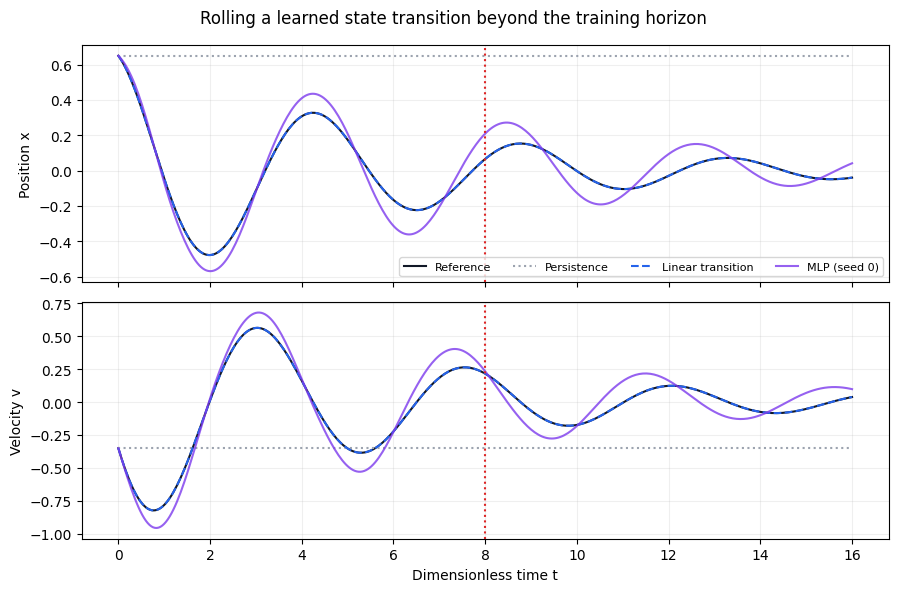

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for column, axis, label in [(0, axes[0], "Position x"), (1, axes[1], "Velocity v")]:
    axis.plot(rollout_time, rollout_reference[:, column], color="#111827", label="Reference")
    axis.plot(rollout_time, transition_rollouts["persistence"][:, column], color="#9ca3af", linestyle=":", label="Persistence")
    axis.plot(rollout_time, transition_rollouts["linear"][:, column], color="#2563eb", linestyle="--", label="Linear transition")
    axis.plot(rollout_time, transition_rollouts["mlp_seed_0"][:, column], color="#7c3aed", alpha=0.8, label="MLP (seed 0)")
    axis.axvline(TRAIN_END, color="#dc2626", linestyle=":")
    axis.set_ylabel(label)
    axis.grid(alpha=0.2)
axes[0].legend(ncol=4, fontsize=8)
axes[-1].set_xlabel("Dimensionless time t")
fig.suptitle("Rolling a learned state transition beyond the training horizon")
plt.tight_layout()
plt.show()

### 7. Time a bounded batch (illustrative, not a universal benchmark)

In [9]:
query_time = np.linspace(0.0, END_TIME, 20_000)
start = perf_counter()
_ = reference_state(query_time)
reference_seconds = perf_counter() - start

start = perf_counter()
_ = model.predict(query_time[:, None])
surrogate_seconds = perf_counter() - start

timing = {
    "queries": len(query_time),
    "analytic_reference_seconds": reference_seconds,
    "surrogate_seconds": surrogate_seconds,
}
print(timing)
print("解析函数本来就很便宜；该计时不能用于声称代理加速了真实数值模拟。")

{'queries': 20000, 'analytic_reference_seconds': 0.0009462920133955777, 'surrogate_seconds': 0.05446608300553635}
解析函数本来就很便宜；该计时不能用于声称代理加速了真实数值模拟。


## Checks

- 插值与外推按时间边界定义，不能随机混在一个测试集；
- 代理与零基线使用同一外推样本；
- 方程残差与状态误差是不同指标，二者都不能单独证明模型可信；
- 计时只描述本机本次运行，且解析参考并不昂贵。

In [10]:
assert full_time[train_indices].max() <= TRAIN_END
assert full_time[extrapolation_indices].min() > TRAIN_END
assert np.isfinite(metrics[["position_mae", "velocity_mae"]].to_numpy()).all()
assert np.isfinite(residual_report.iloc[:, 1:].to_numpy()).all()
assert set(transition_metrics["model"]) == {
    "persistence", "linear", "mlp_seed_0", "mlp_seed_1", "mlp_seed_2"
}
assert transition_metrics.groupby("model").size().eq(2).all()
assert np.isfinite(
    transition_metrics[["position_mae", "velocity_mae", "max_energy_increase"]].to_numpy()
).all()
reference_energy = mechanical_energy(rollout_reference)
assert np.all(np.diff(reference_energy) <= 1e-10)
time_curve_lookup = metrics.set_index(["region", "model"])
print(
    "RESULT_CONTRACT dynamics "
    f"rf_interpolation_position_mae={time_curve_lookup.loc[('训练范围内插值', '随机森林代理'), 'position_mae']:.6f} "
    f"rf_interpolation_velocity_mae={time_curve_lookup.loc[('训练范围内插值', '随机森林代理'), 'velocity_mae']:.6f} "
    f"rf_extrapolation_position_mae={time_curve_lookup.loc[('训练范围外外推', '随机森林代理'), 'position_mae']:.6f} "
    f"rf_extrapolation_velocity_mae={time_curve_lookup.loc[('训练范围外外推', '随机森林代理'), 'velocity_mae']:.6f} "
    f"zero_extrapolation_velocity_mae={time_curve_lookup.loc[('训练范围外外推', '零平衡基线'), 'velocity_mae']:.6f}"
)
print("CONTRACT dynamics: time_split=disjoint transition_models=5 rollout_regions=2 energy_checked=yes")
print("数据边界、误差、滚动和能量检查通过。")

RESULT_CONTRACT dynamics rf_interpolation_position_mae=0.006136 rf_interpolation_velocity_mae=0.008870 rf_extrapolation_position_mae=0.095500 rf_extrapolation_velocity_mae=0.379515 zero_extrapolation_velocity_mae=0.126278
CONTRACT dynamics: time_split=disjoint transition_models=5 rollout_regions=2 energy_checked=yes
数据边界、误差、滚动和能量检查通过。


## Next Steps

1. 改变阻尼和频率，把参数作为输入，测试参数空间外推；
2. 用可微神经网络替代树模型，在训练损失中加入方程残差；
3. 改变滚动步长或加入一步噪声，观察误差如何积累；
4. 在昂贵模拟器上重新设计公平的精度—速度基准。

**结论边界：**本实验说明插值分数不能代表外推可信性；它不证明随机森林不适合所有动力系统，也不证明加入物理损失必然改善所有指标。